In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Uber_Data_Analytics/ncr_ride_bookings.csv')

In [4]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [6]:
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

,0
Date,object
Time,object
Booking ID,object
Booking Status,object
Customer ID,object
Vehicle Type,object
Pickup Location,object
Drop Location,object
Avg VTAT,float64
Avg CTAT,float64


In [9]:
df.shape

(150000, 21)

In [10]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [11]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')
df['Time']=pd.to_datetime(df['Time'],format='%H:%M:%S', errors='coerce').dt.time

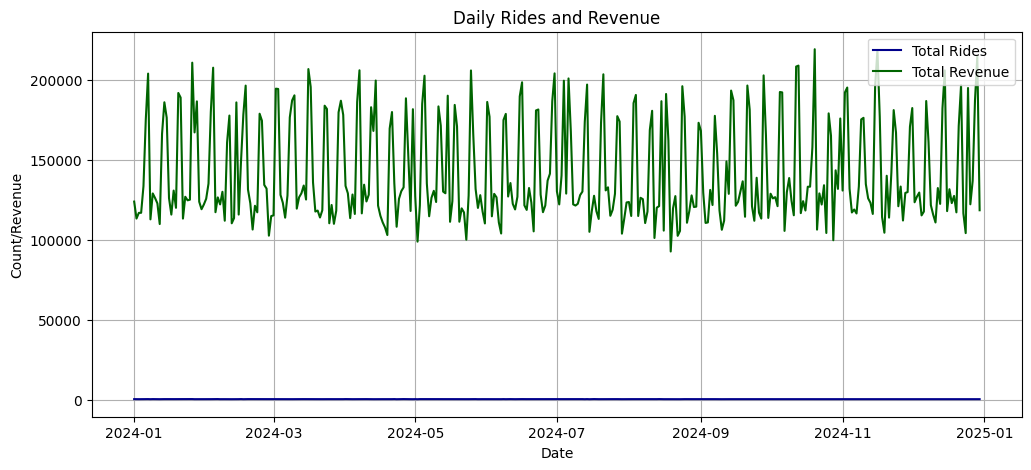

In [12]:
daily_stats = df.groupby('Date').agg({'Booking ID':'count', 'Booking Value' : 'sum'}).reset_index()
plt.figure(figsize=(12,5))
plt.plot(daily_stats['Date'], daily_stats['Booking ID'], label="Total Rides", color='darkblue')
plt.plot(daily_stats['Date'], daily_stats['Booking Value'], label="Total Revenue", color='darkgreen')
plt.title("Daily Rides and Revenue")
plt.xlabel("Date")
plt.ylabel("Count/Revenue")
plt.legend()
plt.grid(True)
plt.show()

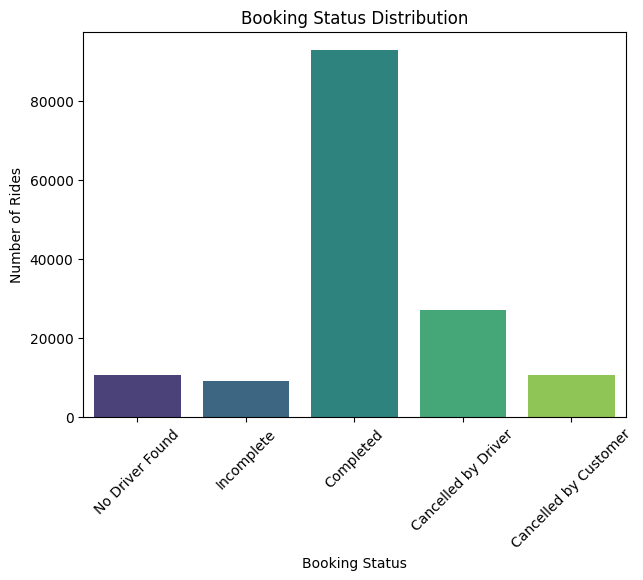

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(x='Booking Status',data=df,palette='viridis')
plt.title("Booking Status Distribution")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.show()

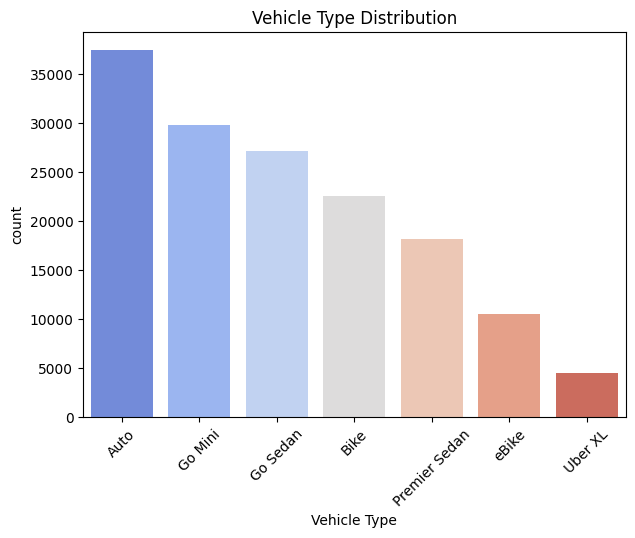

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(x='Vehicle Type', data=df, order=df['Vehicle Type'].value_counts().index, palette='coolwarm')
plt.title("Vehicle Type Distribution")
plt.xticks(rotation=45)
plt.show()

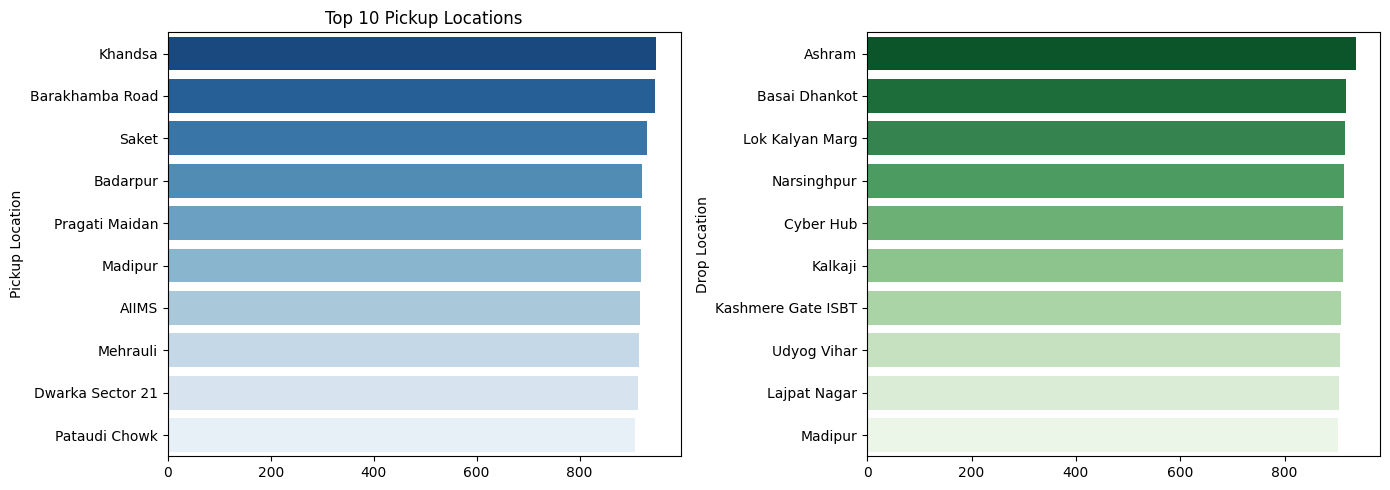

In [19]:
top_pickups = df['Pickup Location'].value_counts().head(10)
top_drops = df['Drop Location'].value_counts().head(10)
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.barplot(x=top_pickups.values, y=top_pickups.index, ax=axes[0], palette='Blues_r')
sns.barplot(x=top_drops.values, y=top_drops.index, ax=axes[1], palette='Greens_r')
axes[0].set_title('Top 10 Pickup Locations')
plt.tight_layout()
plt.show()

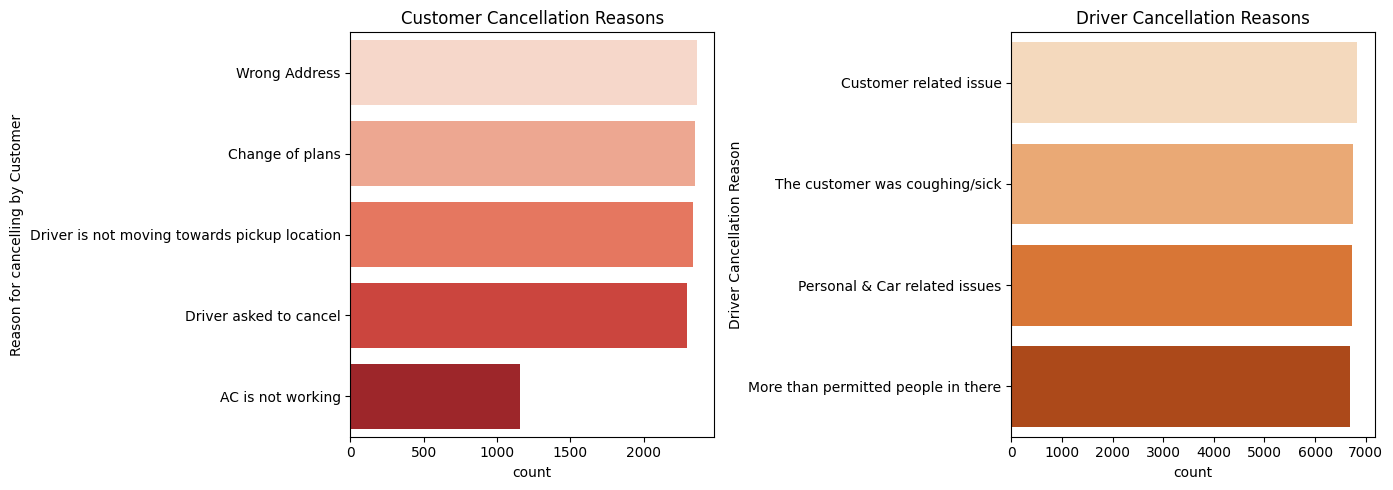

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(y='Reason for cancelling by Customer', data=df, order=df['Reason for cancelling by Customer'].value_counts().index, ax=axes[0], palette='Reds')
axes[0].set_title("Customer Cancellation Reasons")
sns.countplot(y='Driver Cancellation Reason', data=df, order=df['Driver Cancellation Reason'].value_counts().index, ax=axes[1], palette='Oranges')
axes[1].set_title("Driver Cancellation Reasons")
plt.tight_layout()
plt.show()

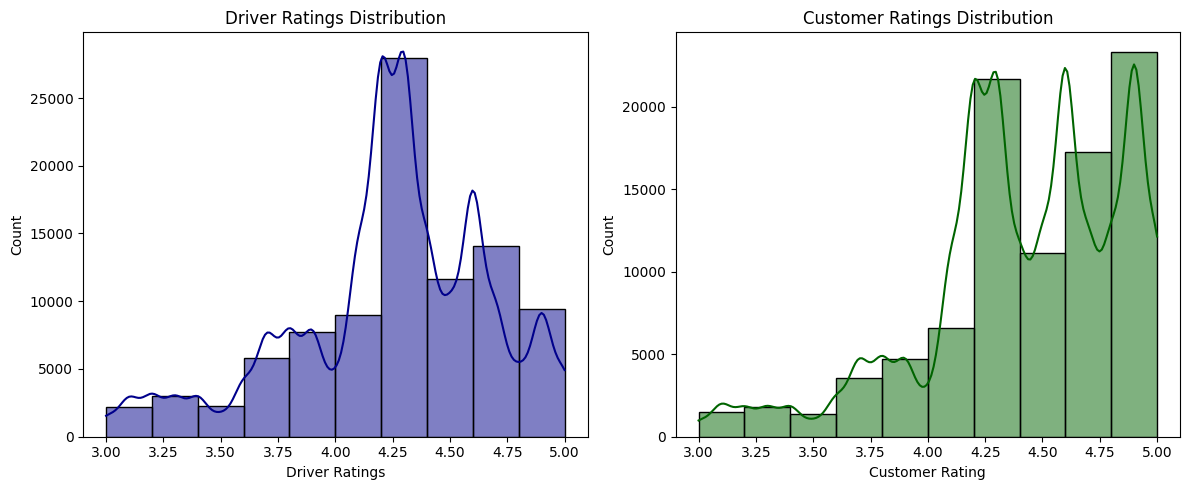

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df['Driver Ratings'], bins=10, kde=True, ax=axes[0], color='darkblue')
axes[0].set_title("Driver Ratings Distribution")
sns.histplot(df['Customer Rating'], bins=10, kde=True, ax=axes[1], color='darkgreen')
axes[1].set_title("Customer Ratings Distribution")
plt.tight_layout()
plt.show()

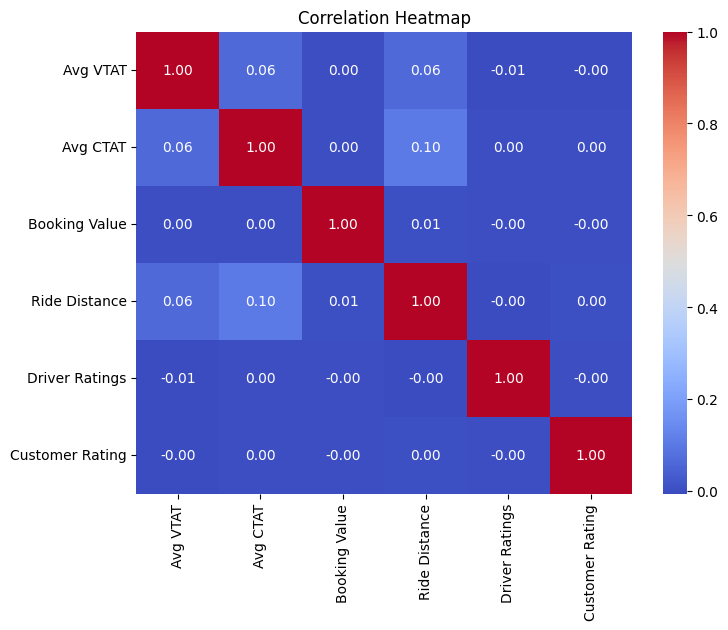

In [23]:
num_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()